# Compositional Contextual Expert Bandits [CCEB]

## Part 1: Defining The Inference System

In [1]:
import torch

# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
from idealobserver import IdealObsPF
from experiment import (
    ExperimentalEnv,
    IOPFSubjectHistory,
    ExperimentHistory,
    CombinedHistory,
)
from particle import print_particle_params

## Part 1: Defining the experiment

### Define the various contexts that can be encountered

In [3]:
NOISE = 0.02
cov_all = torch.eye(2) * NOISE

loc_c0_s0 = torch.tensor([1.0, 0.0])
loc_c0_s1 = torch.tensor([-1.0, 0.0])

loc_c1_s0 = torch.tensor([0.0, 1.0])
loc_c1_s1 = torch.tensor([0.0, -1.0])

context_o_params = {
    0: {  # context 0
        0: {"loc": loc_c0_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c0_s1, "cov": cov_all},  # state 1
    },
    1: {  # context 1
        0: {"loc": loc_c1_s0, "cov": cov_all},  # state 0
        1: {"loc": loc_c1_s1, "cov": cov_all},  # state 1
    },
}

context_r_params = {
    0: {  # context 0
        0: {"p_rew": torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 1.0, 0.0, 0.0])},  # state 1
    },
    1: {  # context 1
        0: {"p_rew": torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {"p_rew": torch.tensor([0.0, 0.0, 0.0, 1.0])},  # state 1
    },
}

In [4]:
env = ExperimentalEnv(
    context_o_params=context_o_params, context_r_params=context_r_params
)

## Part 2: Run Simulation

In [5]:
HYP_CJCRP = {
    "gamma": 0.1,
    "alpha_o": 0.5,
    "alpha_r": 0.5,
}
HYP_NIW = {
    "mu0": torch.tensor([0.0, 0.0]),
    "kappa0": 0.1,
    "nu0": 4.0,
    "Lambda0": torch.eye(2) * 1.0,
}
HYP_BB = {
    "beta0": torch.tensor([0.25, 0.25, 0.25, 0.25]),
    "rho_c": 0.9,
    "rho_i": 0.1,
}

HYP = {"hyp_cjcrp": HYP_CJCRP, "hyp_niw": HYP_NIW, "hyp_bb": HYP_BB}

#### Simulation


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.85  0.22], Action: 0, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.13  0.13], Action: 1, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-0.97  0.04], Action: 2, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.15 -0.18], Action: 3, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-0.81 -0.04], Action: 1, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-0.80  0.06], Action: 3, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.90  0.06], Action: 0, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.96  0.11], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.07 -0.13], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.30 -0.45], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.90 -0.05], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.77  0.18], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.23 -0.18], Action: 1, Reward: 1.0
Step 

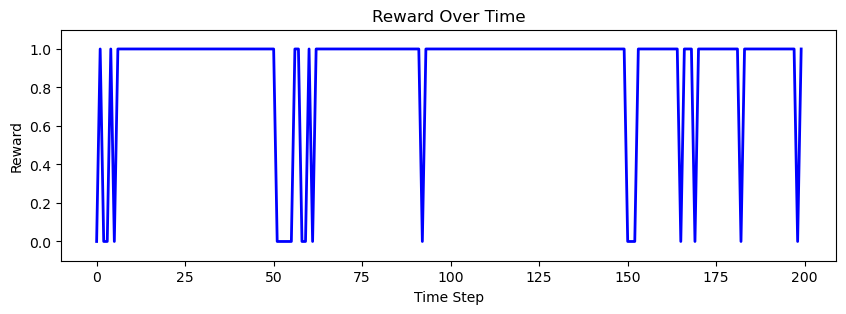


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.94  0.01], Action: 1, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 1.00  0.44], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.01 -0.07], Action: 2, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.80  0.16], Action: 3, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.14  0.21], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.79 -0.13], Action: 1, Reward: 0.0
Step 7:   	True state: 1, Obs.: [-0.91  0.11], Action: 0, Reward: 0.0
Step 8:   	True state: 0, Obs.: [ 1.17 -0.20], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.05  0.12], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.03 -0.09], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.12  0.04], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.80  0.15], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.16  0.02], Action: 0, Reward: 1.0
Step 

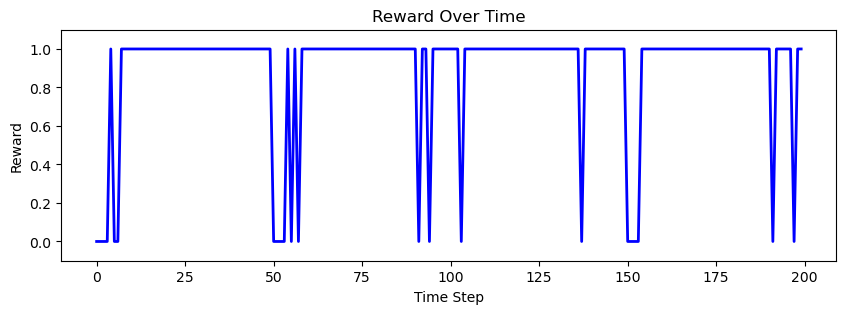


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.16  0.23], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.07  0.12], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.11  0.01], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.87  0.13], Action: 2, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-1.18  0.36], Action: 1, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.09 -0.01], Action: 1, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 1.11 -0.33], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.24  0.10], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.77 -0.01], Action: 1, Reward: 0.0
Step 10:   	True state: 1, Obs.: [-0.59  0.09], Action: 3, Reward: 0.0
Step 11:   	True state: 1, Obs.: [-0.83 -0.18], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.03 -0.08], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.97  0.05], Action: 1, Reward: 1.0
Step 

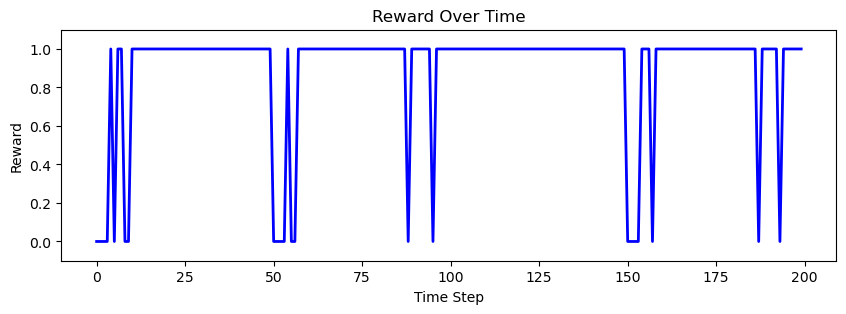


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.25 -0.04], Action: 1, Reward: 1.0
Step 2:   	True state: 0, Obs.: [ 1.09 -0.07], Action: 0, Reward: 1.0
Step 3:   	True state: 0, Obs.: [ 0.92  0.12], Action: 0, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-0.96  0.11], Action: 0, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.12 -0.02], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.01  0.05], Action: 0, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.82  0.10], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.90  0.05], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.06 -0.14], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.96 -0.04], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.07  0.19], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.99 -0.01], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.86 -0.05], Action: 1, Reward: 1.0
Step 

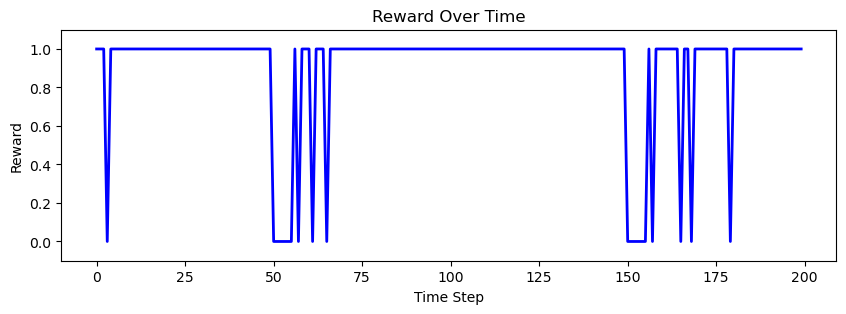


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97 -0.10], Action: 3, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.96  0.22], Action: 1, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-1.20 -0.13], Action: 0, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.86  0.10], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 1.02 -0.08], Action: 0, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-1.00  0.18], Action: 3, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 1.02  0.02], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.87 -0.02], Action: 1, Reward: 0.0
Step 9:   	True state: 0, Obs.: [ 1.25 -0.08], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.14  0.13], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.08  0.04], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.24  0.13], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.10  0.12], Action: 0, Reward: 1.0
Step 

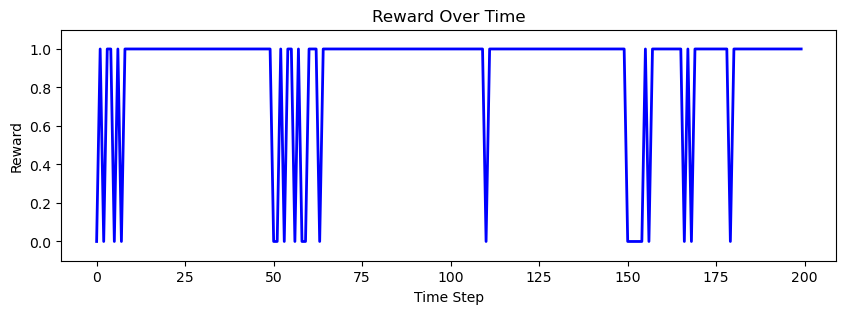


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.16  0.09], Action: 1, Reward: 1.0
Step 2:   	True state: 1, Obs.: [-1.02 -0.10], Action: 1, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-1.00  0.17], Action: 1, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-0.94 -0.03], Action: 1, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-0.99 -0.18], Action: 0, Reward: 0.0
Step 6:   	True state: 1, Obs.: [-1.00  0.08], Action: 2, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.95 -0.13], Action: 2, Reward: 0.0
Step 8:   	True state: 1, Obs.: [-1.17  0.01], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.05  0.12], Action: 1, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.04  0.06], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-1.07  0.22], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.82  0.04], Action: 2, Reward: 0.0
Step 13:   	True state: 1, Obs.: [-1.25  0.18], Action: 1, Reward: 1.0
Step 

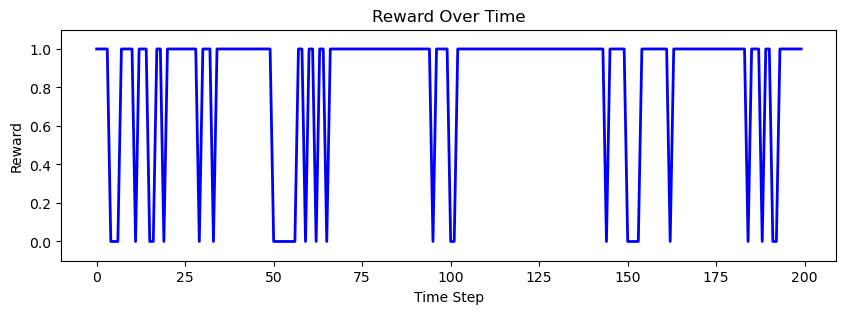


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.10  0.08], Action: 1, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 1.07  0.05], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-1.03 -0.06], Action: 3, Reward: 0.0
Step 4:   	True state: 0, Obs.: [ 1.17  0.23], Action: 2, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-0.98 -0.05], Action: 2, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 1.16 -0.25], Action: 0, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.87 -0.28], Action: 0, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-1.27  0.12], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-0.75  0.24], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.87  0.10], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.86 -0.05], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.90 -0.09], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.05 -0.00], Action: 0, Reward: 1.0
Step 

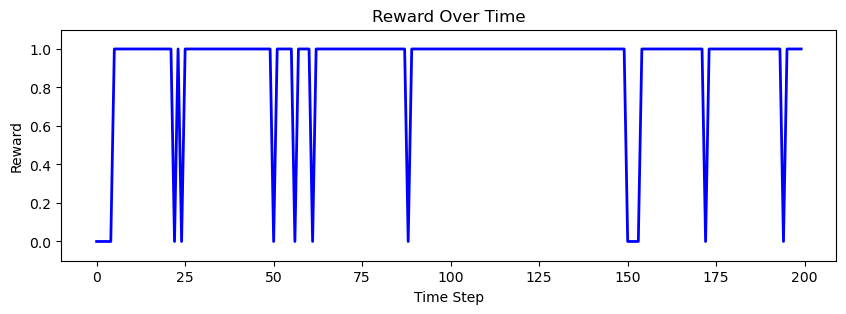


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.09 -0.11], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.05  0.12], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.95 -0.13], Action: 1, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-1.04 -0.16], Action: 1, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-0.95  0.06], Action: 1, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.97  0.04], Action: 1, Reward: 0.0
Step 7:   	True state: 1, Obs.: [-1.03 -0.05], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.98 -0.13], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-0.91  0.07], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.08 -0.21], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.82 -0.08], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 1.09 -0.08], Action: 0, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 0.86 -0.06], Action: 0, Reward: 1.0
Step 

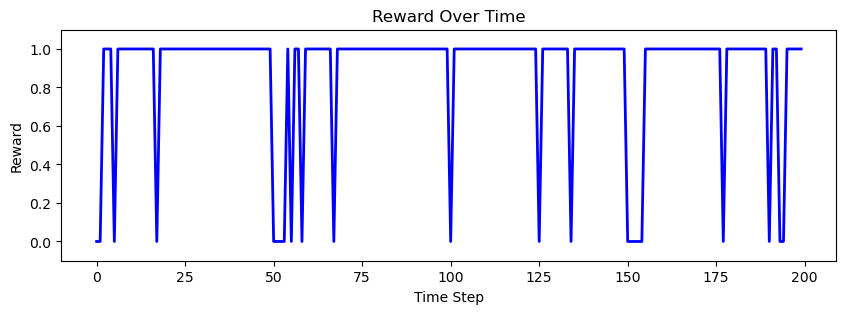


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.24  0.03], Action: 0, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 0.95  0.02], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.88 -0.01], Action: 0, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.21  0.08], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 0.89  0.18], Action: 1, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 0.89  0.05], Action: 0, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.14 -0.10], Action: 1, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-1.16 -0.14], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.93 -0.24], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.12 -0.12], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.98 -0.10], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.98 -0.11], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.18 -0.12], Action: 1, Reward: 1.0
Step 

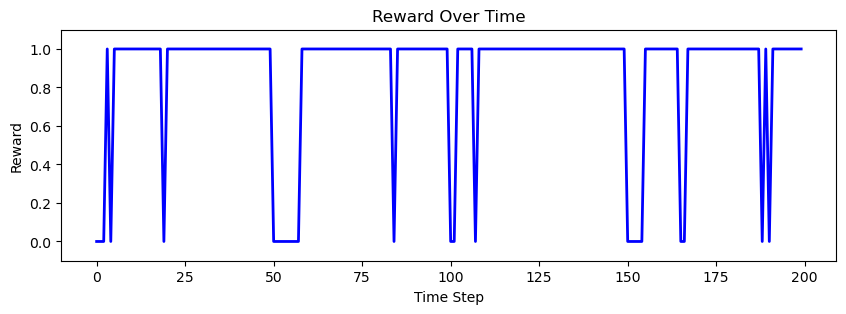


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.17  0.07], Action: 3, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.68  0.15], Action: 0, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-1.20  0.00], Action: 1, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 1.16 -0.01], Action: 3, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.18  0.15], Action: 2, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 0.84  0.13], Action: 0, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.84  0.02], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.03  0.06], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.14  0.08], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.08  0.05], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-1.23 -0.11], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 1.18  0.11], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.06 -0.03], Action: 1, Reward: 1.0
Step 

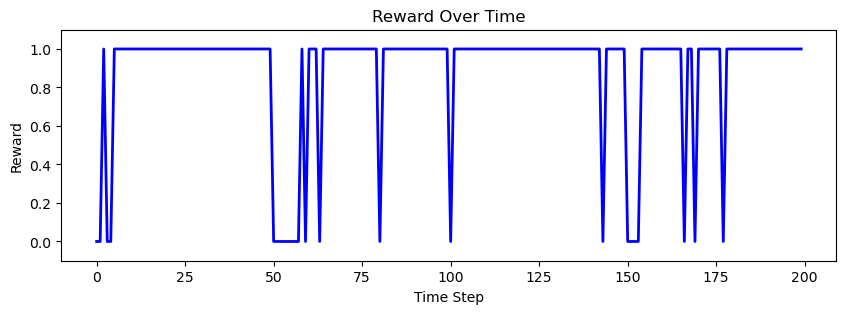


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97  0.14], Action: 0, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 0.89  0.06], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.07  0.20], Action: 0, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-0.86 -0.30], Action: 2, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-0.74  0.24], Action: 0, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 1.03  0.23], Action: 0, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.01  0.11], Action: 3, Reward: 0.0
Step 8:   	True state: 0, Obs.: [ 1.06  0.03], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.73 -0.11], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.12  0.13], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.88 -0.06], Action: 0, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.99  0.06], Action: 0, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 0.80 -0.18], Action: 0, Reward: 1.0
Step 

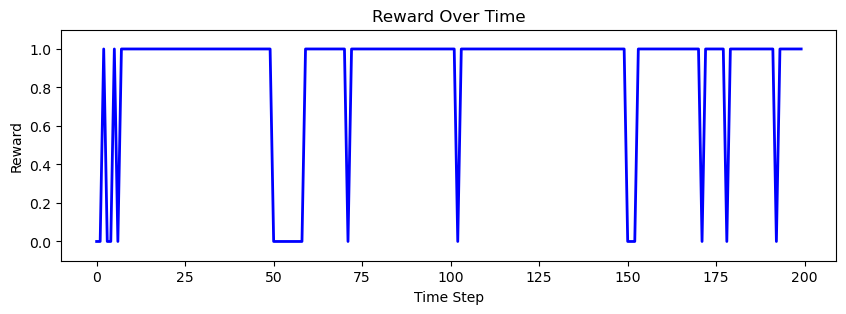


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.93 -0.06], Action: 3, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.45  0.10], Action: 2, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.22  0.01], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.09  0.01], Action: 1, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-1.24  0.13], Action: 1, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.05 -0.25], Action: 2, Reward: 0.0
Step 7:   	True state: 1, Obs.: [-1.00  0.02], Action: 1, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.91  0.00], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-0.71 -0.03], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.83 -0.27], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.05 -0.15], Action: 0, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.78  0.19], Action: 0, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 0.86 -0.05], Action: 0, Reward: 1.0
Step 

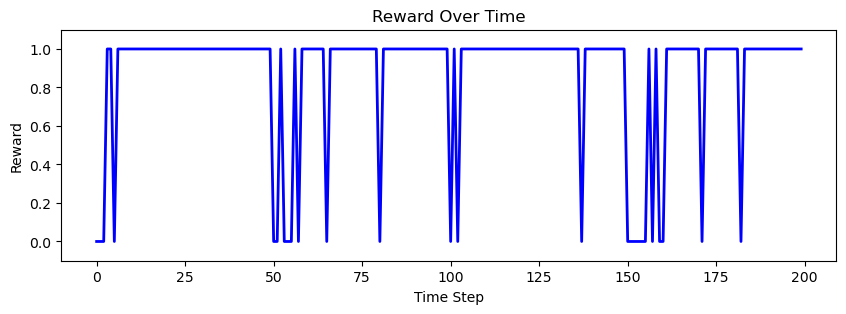


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.08 -0.06], Action: 2, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 1.06  0.06], Action: 0, Reward: 1.0
Step 3:   	True state: 0, Obs.: [ 0.98 -0.30], Action: 0, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-1.18  0.08], Action: 2, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.12 -0.01], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.08 -0.06], Action: 0, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-0.82 -0.02], Action: 1, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-1.16  0.10], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.73 -0.10], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.17  0.28], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.74 -0.15], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.86 -0.35], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.01  0.10], Action: 0, Reward: 1.0
Step 

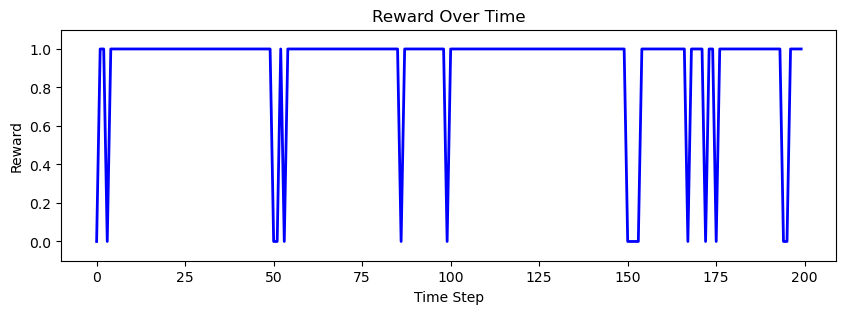


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.94  0.21], Action: 0, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.92 -0.13], Action: 1, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-1.14 -0.18], Action: 1, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 0.69  0.11], Action: 2, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-1.22 -0.06], Action: 1, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-1.21  0.02], Action: 1, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 1.00 -0.18], Action: 1, Reward: 0.0
Step 8:   	True state: 1, Obs.: [-1.08 -0.09], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.08 -0.02], Action: 1, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.02 -0.01], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.16 -0.33], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.27 -0.26], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 0.98  0.01], Action: 0, Reward: 1.0
Step 

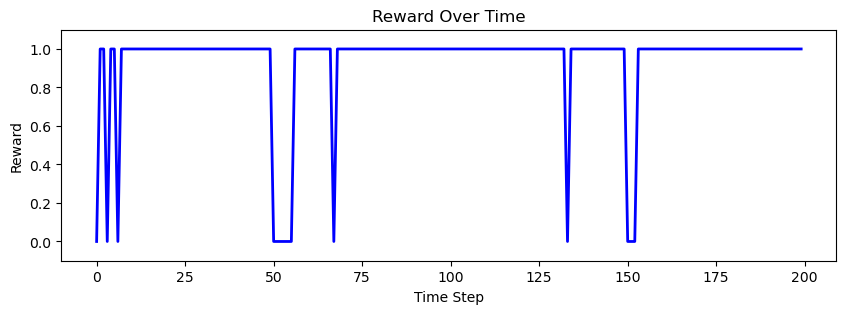


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.10 -0.10], Action: 0, Reward: 1.0
Step 2:   	True state: 0, Obs.: [ 0.88 -0.08], Action: 0, Reward: 1.0
Step 3:   	True state: 0, Obs.: [ 0.96 -0.12], Action: 0, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 1.06 -0.08], Action: 0, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 0.90 -0.23], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.79  0.07], Action: 0, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.93 -0.04], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.87 -0.12], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.13 -0.13], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-0.97  0.07], Action: 0, Reward: 0.0
Step 11:   	True state: 1, Obs.: [-1.01 -0.10], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.19 -0.06], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.21 -0.10], Action: 0, Reward: 1.0
Step 

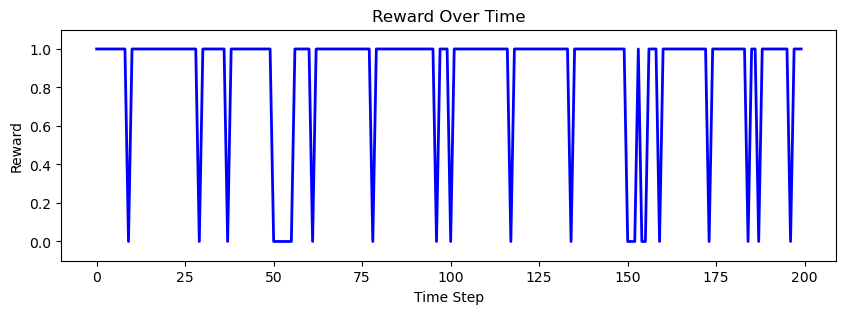


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.19 -0.18], Action: 3, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 1.00 -0.27], Action: 2, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 0.97 -0.10], Action: 3, Reward: 0.0
Step 4:   	True state: 0, Obs.: [ 0.95  0.19], Action: 1, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-1.06 -0.07], Action: 0, Reward: 0.0
Step 6:   	True state: 1, Obs.: [-0.78  0.08], Action: 1, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.10 -0.03], Action: 1, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.96 -0.45], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.07 -0.32], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.92  0.22], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.98  0.04], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.00  0.04], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.25 -0.18], Action: 0, Reward: 1.0
Step 

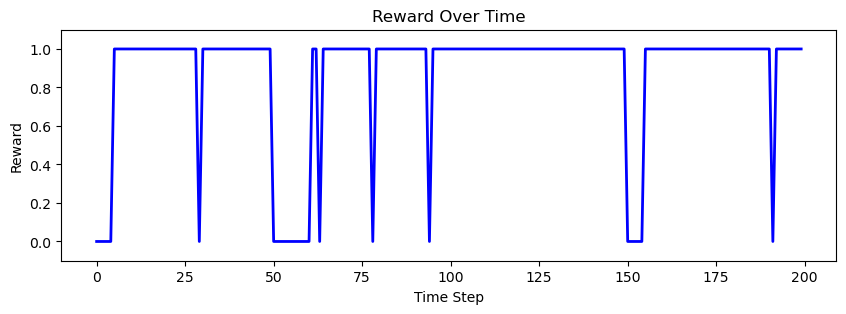


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.20 -0.04], Action: 1, Reward: 1.0
Step 2:   	True state: 1, Obs.: [-0.88 -0.13], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.93 -0.00], Action: 1, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 0.99 -0.23], Action: 2, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 0.93  0.09], Action: 1, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 1.08 -0.27], Action: 3, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.96 -0.11], Action: 2, Reward: 0.0
Step 8:   	True state: 1, Obs.: [-1.26  0.03], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.86  0.28], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.93 -0.21], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.89 -0.01], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.99  0.11], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.12 -0.01], Action: 1, Reward: 1.0
Step 

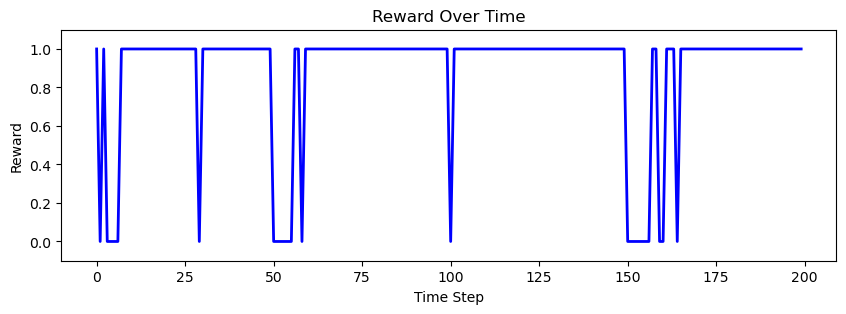


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.91  0.14], Action: 1, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.07 -0.15], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 0.81 -0.27], Action: 0, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-1.30 -0.16], Action: 2, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.18  0.19], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.03  0.01], Action: 0, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-0.86 -0.14], Action: 0, Reward: 0.0
Step 8:   	True state: 1, Obs.: [-0.92  0.15], Action: 1, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-0.95 -0.06], Action: 1, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.02 -0.08], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.97 -0.29], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.30 -0.31], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.98 -0.08], Action: 1, Reward: 1.0
Step 

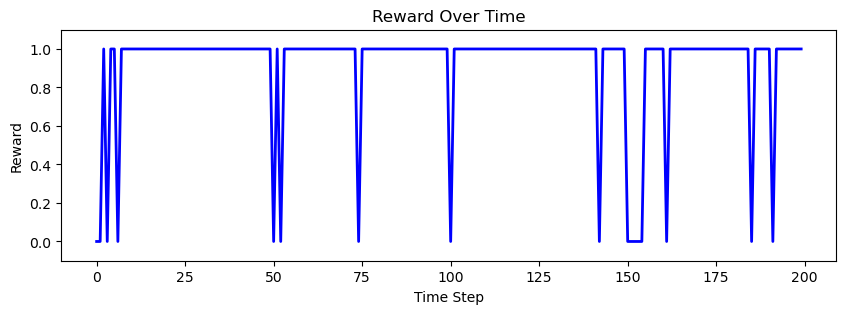


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.92  0.06], Action: 3, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 0.99 -0.18], Action: 1, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.89  0.17], Action: 0, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.91  0.03], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 1.11  0.14], Action: 0, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-0.88  0.23], Action: 1, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.11  0.46], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.93 -0.23], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.16 -0.06], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.21  0.14], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.89  0.01], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.89  0.19], Action: 0, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.11  0.08], Action: 0, Reward: 1.0
Step 

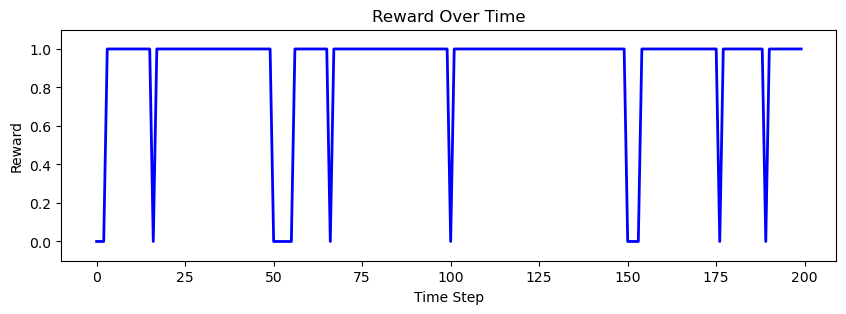


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.92  0.15], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.05  0.03], Action: 1, Reward: 1.0
Step 3:   	True state: 0, Obs.: [ 1.08 -0.03], Action: 0, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-1.01 -0.21], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 0.84  0.04], Action: 0, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-0.91  0.24], Action: 1, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 1.07  0.06], Action: 0, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.77 -0.10], Action: 0, Reward: 0.0
Step 9:   	True state: 0, Obs.: [ 0.98  0.01], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.09 -0.16], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.94 -0.18], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.11 -0.30], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.22 -0.12], Action: 1, Reward: 1.0
Step 

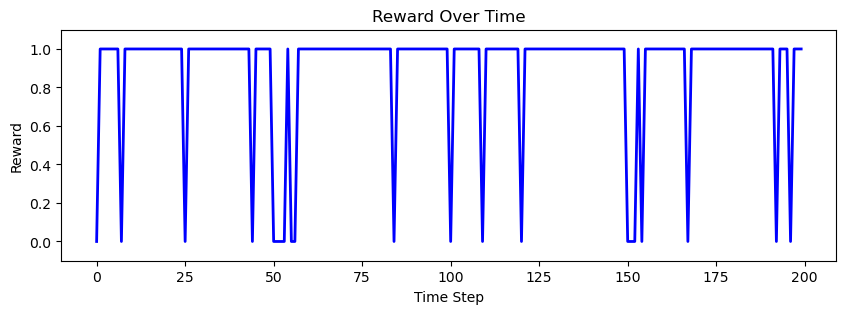


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.08  0.13], Action: 3, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 0.91  0.05], Action: 0, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-0.84  0.09], Action: 0, Reward: 0.0
Step 4:   	True state: 0, Obs.: [ 0.78  0.03], Action: 0, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-0.90  0.25], Action: 3, Reward: 0.0
Step 6:   	True state: 1, Obs.: [-0.87  0.11], Action: 1, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.97  0.01], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.03  0.23], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.17 -0.09], Action: 1, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.02  0.20], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-1.00  0.00], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.06  0.03], Action: 1, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.05  0.12], Action: 0, Reward: 1.0
Step 

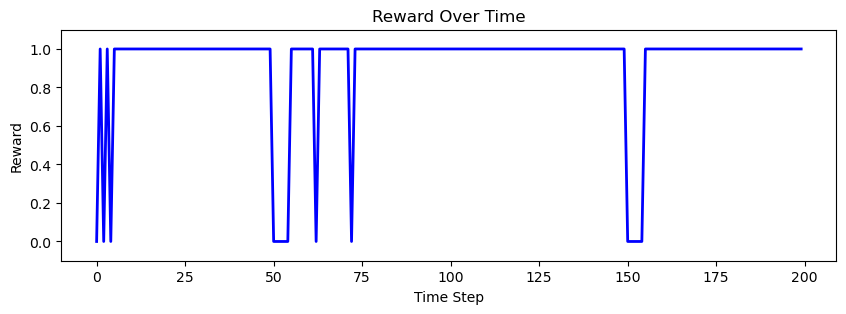


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97 -0.06], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.16  0.17], Action: 0, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-1.09 -0.08], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.07 -0.02], Action: 1, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-0.96  0.25], Action: 1, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.87  0.28], Action: 1, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.91  0.24], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.94  0.10], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.07  0.19], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.09 -0.02], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.90 -0.05], Action: 0, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.83 -0.01], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.95  0.07], Action: 1, Reward: 1.0
Step 

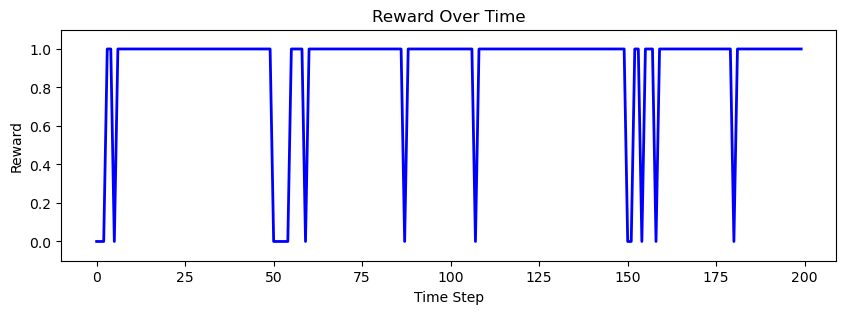


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.06  0.03], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.11 -0.08], Action: 1, Reward: 1.0
Step 3:   	True state: 1, Obs.: [-0.88 -0.12], Action: 1, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 1.21  0.09], Action: 3, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.00 -0.16], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.86  0.06], Action: 1, Reward: 0.0
Step 7:   	True state: 1, Obs.: [-0.83 -0.03], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.90 -0.12], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.32 -0.12], Action: 1, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.81 -0.18], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-1.08 -0.03], Action: 1, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 1.08  0.20], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.05  0.13], Action: 1, Reward: 1.0
Step 

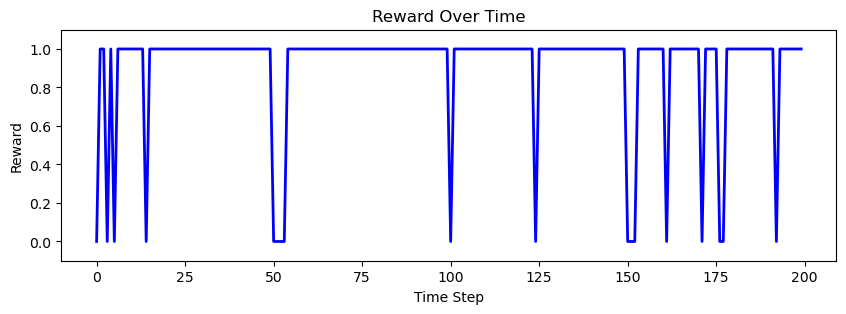


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.95 -0.08], Action: 3, Reward: 0.0
Step 2:   	True state: 0, Obs.: [ 0.98 -0.25], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 0.90 -0.08], Action: 1, Reward: 0.0
Step 4:   	True state: 0, Obs.: [ 0.94 -0.19], Action: 3, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 1.04  0.04], Action: 0, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-1.11 -0.11], Action: 0, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.90 -0.01], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.79  0.06], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.23 -0.04], Action: 2, Reward: 0.0
Step 10:   	True state: 0, Obs.: [ 0.98  0.13], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.99  0.02], Action: 1, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-1.03 -0.01], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.98  0.02], Action: 1, Reward: 1.0
Step 

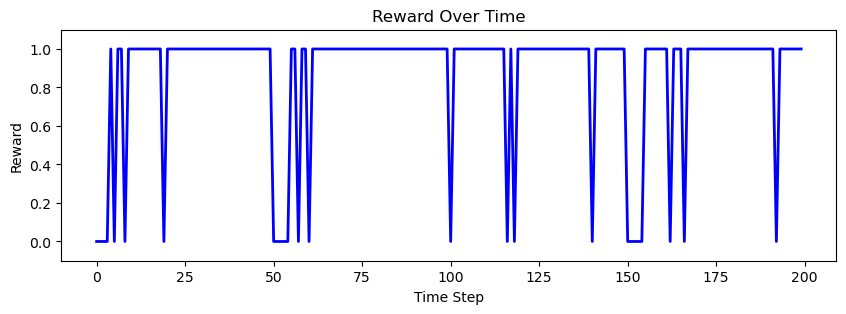


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.72  0.04], Action: 0, Reward: 1.0
Step 2:   	True state: 1, Obs.: [-0.91  0.02], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.99  0.06], Action: 0, Reward: 0.0
Step 4:   	True state: 0, Obs.: [ 0.96  0.15], Action: 0, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 0.89  0.10], Action: 0, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 0.89 -0.19], Action: 0, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.02  0.08], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.13 -0.07], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.96  0.05], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.89  0.16], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.93 -0.14], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.76  0.06], Action: 2, Reward: 0.0
Step 13:   	True state: 0, Obs.: [ 0.75 -0.11], Action: 0, Reward: 1.0
Step 

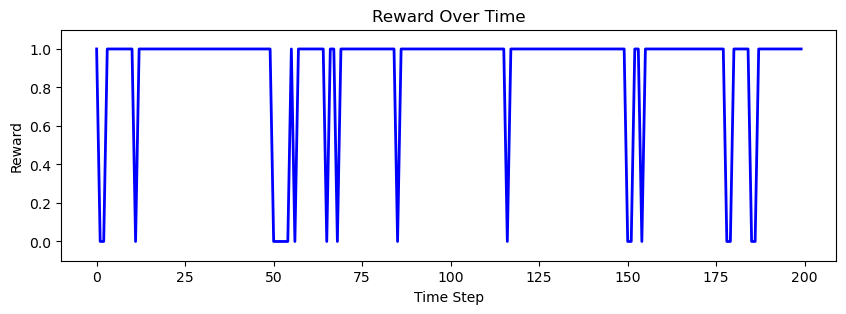


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.90  0.09], Action: 0, Reward: 1.0
Step 2:   	True state: 1, Obs.: [-0.78 -0.17], Action: 0, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.06  0.07], Action: 0, Reward: 1.0
Step 4:   	True state: 0, Obs.: [ 1.05 -0.08], Action: 0, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-1.27  0.02], Action: 2, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 1.19 -0.06], Action: 0, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 0.77 -0.06], Action: 0, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.11 -0.07], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 1.03  0.17], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 1.26  0.09], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.87  0.06], Action: 3, Reward: 0.0
Step 12:   	True state: 1, Obs.: [-1.13  0.09], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.06 -0.06], Action: 1, Reward: 1.0
Step 

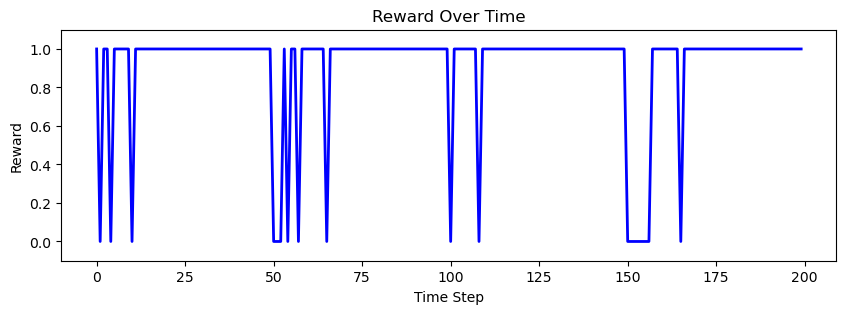


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.00 -0.02], Action: 0, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.86 -0.06], Action: 2, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.62  0.13], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.90 -0.12], Action: 0, Reward: 0.0
Step 5:   	True state: 0, Obs.: [ 0.91  0.02], Action: 1, Reward: 0.0
Step 6:   	True state: 0, Obs.: [ 0.87  0.08], Action: 2, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 1.03 -0.31], Action: 1, Reward: 0.0
Step 8:   	True state: 0, Obs.: [ 0.83  0.15], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.92 -0.07], Action: 0, Reward: 1.0
Step 10:   	True state: 0, Obs.: [ 0.94 -0.27], Action: 0, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.62 -0.03], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.73 -0.13], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.85  0.08], Action: 1, Reward: 1.0
Step 

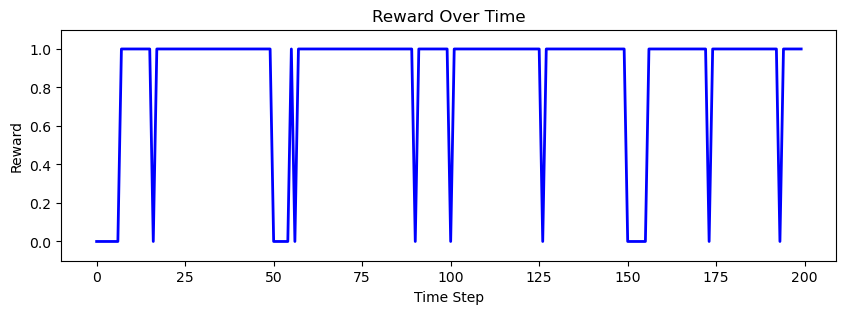


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.79  0.03], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.03  0.11], Action: 3, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 0.62  0.15], Action: 1, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.02 -0.11], Action: 0, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-0.98  0.10], Action: 1, Reward: 1.0
Step 6:   	True state: 0, Obs.: [ 1.05 -0.34], Action: 3, Reward: 0.0
Step 7:   	True state: 1, Obs.: [-0.87  0.12], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 0.96 -0.15], Action: 0, Reward: 1.0
Step 9:   	True state: 1, Obs.: [-1.15 -0.20], Action: 1, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-0.94 -0.21], Action: 1, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-0.88  0.13], Action: 0, Reward: 0.0
Step 12:   	True state: 0, Obs.: [ 1.12  0.07], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-0.80  0.07], Action: 1, Reward: 1.0
Step 

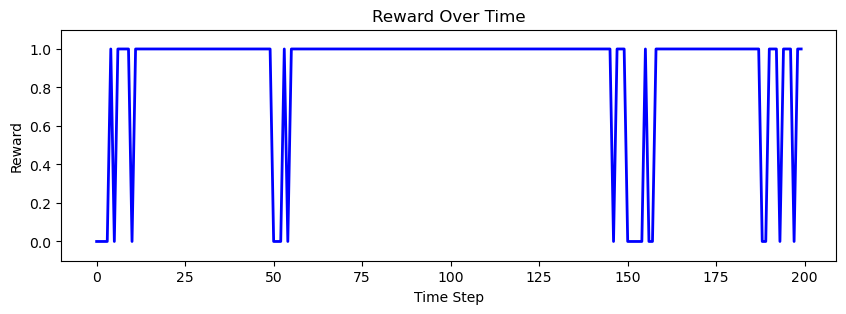


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.98  0.21], Action: 0, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-0.88  0.01], Action: 1, Reward: 1.0
Step 3:   	True state: 0, Obs.: [ 0.84 -0.19], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.14 -0.07], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 1.06  0.21], Action: 1, Reward: 0.0
Step 6:   	True state: 1, Obs.: [-0.95 -0.09], Action: 1, Reward: 1.0
Step 7:   	True state: 0, Obs.: [ 1.07 -0.06], Action: 2, Reward: 0.0
Step 8:   	True state: 1, Obs.: [-0.98 -0.14], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.90 -0.14], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-1.27 -0.02], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 1.20  0.08], Action: 0, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.88  0.01], Action: 1, Reward: 0.0
Step 13:   	True state: 1, Obs.: [-0.67  0.03], Action: 1, Reward: 1.0
Step 

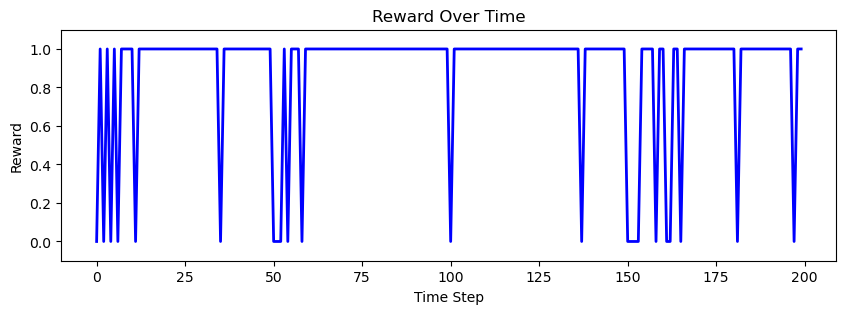


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.06  0.26], Action: 1, Reward: 1.0
Step 2:   	True state: 0, Obs.: [ 0.97  0.33], Action: 2, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.03 -0.02], Action: 3, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-1.24  0.15], Action: 1, Reward: 1.0
Step 5:   	True state: 0, Obs.: [ 0.99  0.08], Action: 0, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-0.99 -0.05], Action: 1, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-1.13 -0.01], Action: 1, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.97  0.02], Action: 1, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.91  0.17], Action: 0, Reward: 1.0
Step 10:   	True state: 1, Obs.: [-0.99  0.11], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.92 -0.18], Action: 0, Reward: 1.0
Step 12:   	True state: 1, Obs.: [-0.86 -0.17], Action: 1, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.00 -0.14], Action: 1, Reward: 1.0
Step 

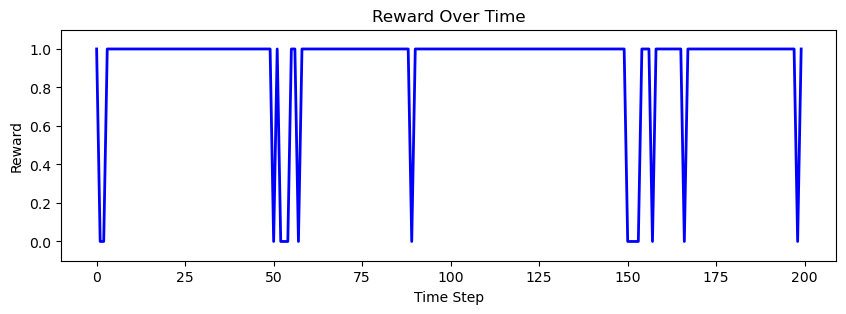


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.02  0.32], Action: 2, Reward: 0.0
Step 2:   	True state: 1, Obs.: [-1.05 -0.17], Action: 0, Reward: 0.0
Step 3:   	True state: 0, Obs.: [ 1.00  0.38], Action: 2, Reward: 0.0
Step 4:   	True state: 1, Obs.: [-0.87  0.02], Action: 0, Reward: 0.0
Step 5:   	True state: 1, Obs.: [-1.08  0.04], Action: 2, Reward: 0.0
Step 6:   	True state: 1, Obs.: [-1.09  0.04], Action: 0, Reward: 0.0
Step 7:   	True state: 0, Obs.: [ 0.96  0.10], Action: 0, Reward: 1.0
Step 8:   	True state: 1, Obs.: [-0.94 -0.23], Action: 3, Reward: 0.0
Step 9:   	True state: 1, Obs.: [-0.96 -0.02], Action: 2, Reward: 0.0
Step 10:   	True state: 0, Obs.: [ 1.08 -0.08], Action: 0, Reward: 1.0
Step 11:   	True state: 1, Obs.: [-1.05 -0.06], Action: 3, Reward: 0.0
Step 12:   	True state: 0, Obs.: [ 1.13 -0.19], Action: 0, Reward: 1.0
Step 13:   	True state: 0, Obs.: [ 1.08 -0.07], Action: 0, Reward: 1.0
Step 

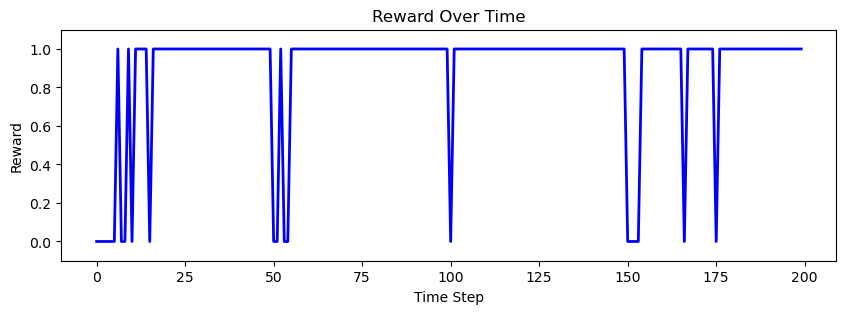


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.03 -0.24], Action: 1, Reward: 1.0
Step 2:   	True state: 0, Obs.: [ 0.86  0.24], Action: 3, Reward: 0.0
Step 3:   	True state: 1, Obs.: [-0.99 -0.05], Action: 1, Reward: 1.0
Step 4:   	True state: 1, Obs.: [-1.03  0.06], Action: 1, Reward: 1.0
Step 5:   	True state: 1, Obs.: [-0.98 -0.03], Action: 1, Reward: 1.0
Step 6:   	True state: 1, Obs.: [-0.91 -0.10], Action: 1, Reward: 1.0
Step 7:   	True state: 1, Obs.: [-0.97 -0.05], Action: 1, Reward: 1.0
Step 8:   	True state: 0, Obs.: [ 1.13  0.08], Action: 0, Reward: 1.0
Step 9:   	True state: 0, Obs.: [ 0.93  0.21], Action: 2, Reward: 0.0
Step 10:   	True state: 1, Obs.: [-0.88 -0.09], Action: 1, Reward: 1.0
Step 11:   	True state: 0, Obs.: [ 0.99  0.11], Action: 0, Reward: 1.0
Step 12:   	True state: 0, Obs.: [ 0.96  0.05], Action: 0, Reward: 1.0
Step 13:   	True state: 1, Obs.: [-1.15 -0.11], Action: 1, Reward: 1.0
Step 

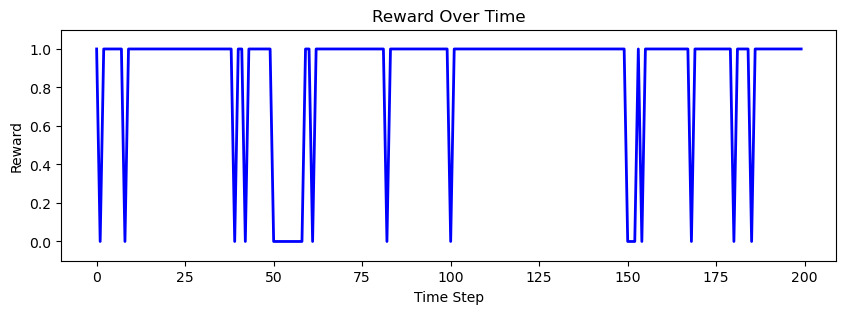

In [6]:
results = []

for i in range(32):

    # Initialize history buffers
    exp_history = ExperimentHistory()
    sub_history = IOPFSubjectHistory()

    # Initialize ensemble
    subject = IdealObsPF(N=250, hyp_params=HYP, n_workers=8)
    # ensemble = Ensemble(N=1000, hyp_cjcrp=HYP_CJCRP, hyp_niw=HYP_NIW, hyp_bb=HYP_BB)

    # Run 50 trials in context (c_o=0, c_r=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c_o=0,
        c_r=0,
        print_level=3,
    )
    # Run 50 trials in context (c_o=1, c_r=1)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c_o=1,
        c_r=1,
        print_level=3,
    )
    # Run 50 trials in context (c_o=0, c_r=0)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c_o=0,
        c_r=0,
        print_level=3,
    )
    # Run 50 trials in context (c_o=0, c_r=1)
    env.repeat_trials(
        subject,
        experiment_history=exp_history,
        subject_history=sub_history,
        N=50,
        c_o=0,
        c_r=1,
        print_level=3,
    )

    subject.deallocate()

    # Combine histories into single object
    combined_history = CombinedHistory(
        subject_history=sub_history, experiment_history=exp_history
    )

    results.append(combined_history)

    plt.figure(figsize=(10, 3))
    plt.plot(
        combined_history.experiment_history.reward,
        label="Reward",
        color="blue",
        linewidth=2,
    )
    plt.title("Reward Over Time")
    plt.xlabel("Time Step")
    plt.ylabel("Reward")
    plt.ylim(-0.1, 1.1)
    plt.show()

In [7]:
# for particle in subject.particles:
#     print(f"\n>> Particle {particle}:\n")
#     print_particle_params(particle)

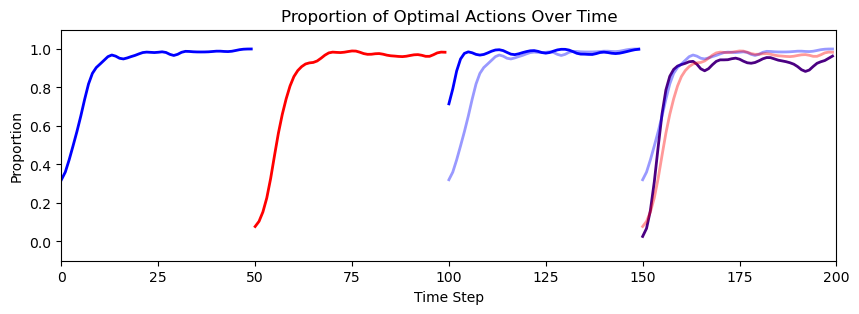

In [8]:
proportion_optimal_mean = np.zeros(200)

chosen = list(range(32))

for j in chosen:

    proportion_optimal_mean += np.array(results[j].experiment_history.reward)

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d


def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)


task_1 = smooth(proportion_optimal_mean[0:50])
task_1_dur = np.arange(0, 50)
task_2 = smooth(proportion_optimal_mean[50:100])
task_2_dur = np.arange(50, 100)
task_3 = smooth(proportion_optimal_mean[100:150])
task_3_dur = np.arange(100, 150)
task_4 = smooth(proportion_optimal_mean[150:200])
task_4_dur = np.arange(150, 200)


plt.figure(figsize=(10, 3))
# plt.plot(proportion_optimal_mean, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.plot(task_1_dur, task_1, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_2_dur, task_2, color="red", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_3, color="blue", linewidth=2, alpha=1.0)
plt.plot(task_4_dur, task_4, color="indigo", linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_1, color="blue", linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_2, color="red", linewidth=2, alpha=0.4)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(-0.1, 1.1)
plt.xlim(0, len(proportion_optimal_mean))
# plt.savefig("g_proportion_optimal_3.pdf")
plt.show()

In [9]:
binary_res = np.array(
    [results[i].experiment_history.reward for i in range(32)], dtype=np.int8
)
binary_res_task_1 = binary_res[:, 0:50]
binary_res_task_2 = binary_res[:, 50:100]
binary_res_task_3 = binary_res[:, 100:150]
binary_res_task_4 = binary_res[:, 150:200]
np.savetxt("task1.csv", binary_res_task_1, delimiter=",")
np.savetxt("task2.csv", binary_res_task_2, delimiter=",")
np.savetxt("task3.csv", binary_res_task_3, delimiter=",")
np.savetxt("task4.csv", binary_res_task_4, delimiter=",")

## Part 3: Analysis of Results

#### Sanity check of inferred parameters

### Visualisation of Results

Context O History:


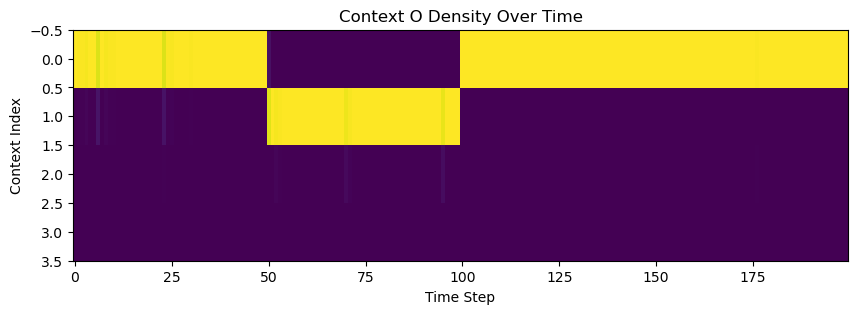

Context R History:


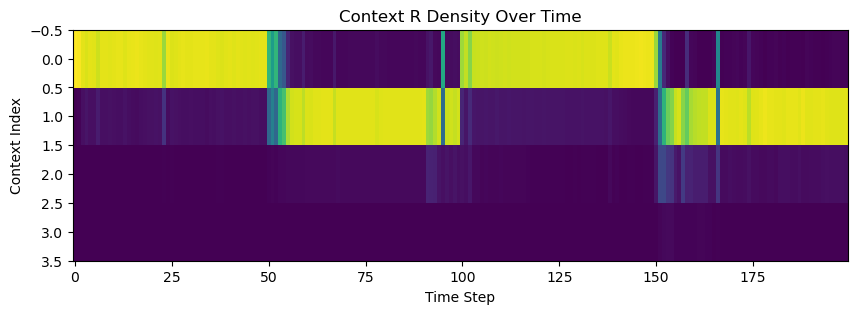

Actions History:


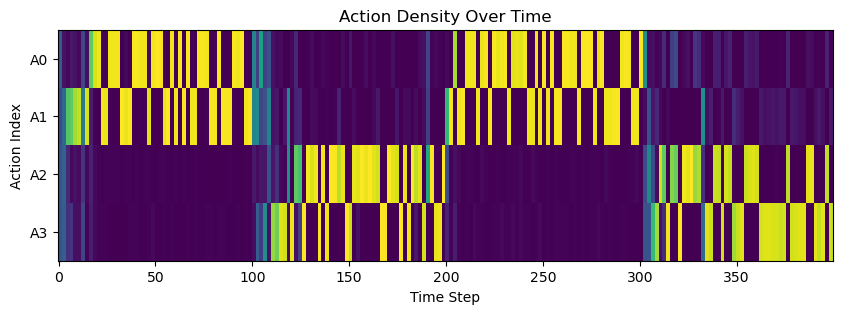

Proportion of Optimal Actions Over Time:


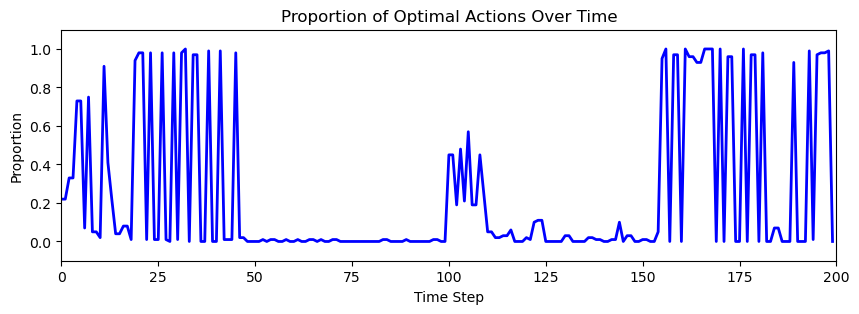

Jump History:


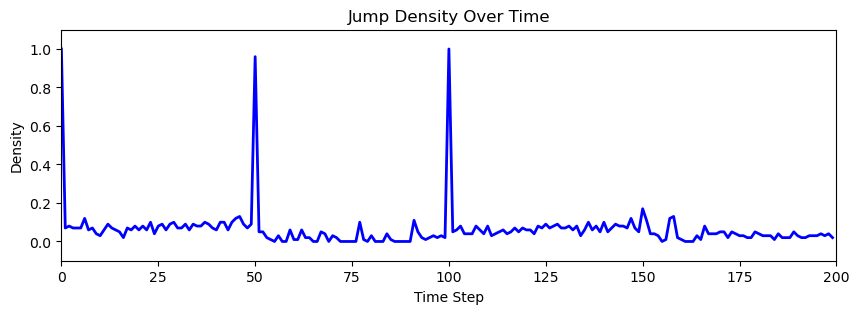

Inferred S History:


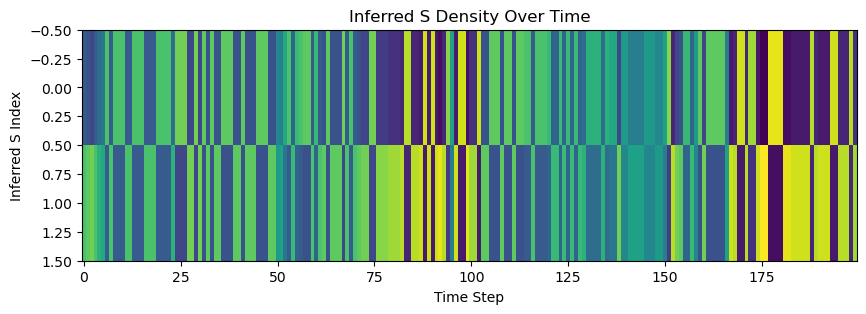

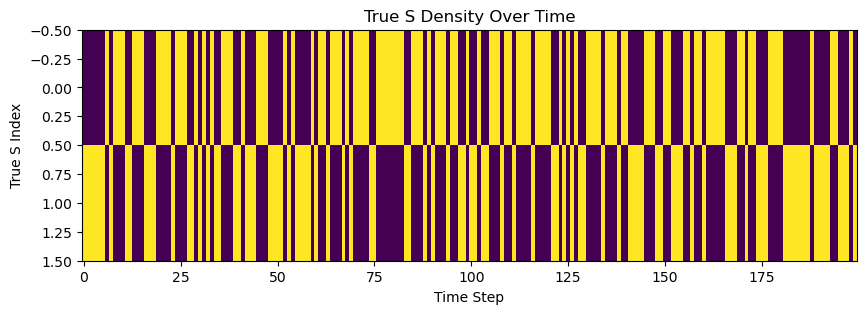

In [10]:
jump_times = []
j = 0
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context O History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(
    axis=1, keepdims=True
)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(
    context_o_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)


plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context O Density Over Time")
# plt.savefig("g_context_o_density.pdf")
plt.show()

print("Context R History:")
max_context_r = np.max(context_r_hist_arr) + 1
context_r_densities = np.zeros((len(context_r_hist_arr), max_context_r))
for t, element in enumerate(context_r_hist_arr):
    for particle_id, val in enumerate(element):
        context_r_densities[t, val] += weight_arr[t][particle_id]
context_r_densities = context_r_densities / context_r_densities.sum(
    axis=1, keepdims=True
)

plt.figure(figsize=(10, 3))
plt.imshow(
    context_r_densities.T, aspect="auto", cmap="viridis", interpolation="nearest"
)
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Context Index")
plt.title("Context R Density Over Time")
# plt.savefig("g_context_r_density.pdf")
plt.show()

print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=["A0", "A1", "A2", "A3"])
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Action Index")
plt.title("Action Density Over Time")
# plt.savefig("g_action_density.pdf")
plt.show()

print("Proportion of Optimal Actions Over Time:")

plt.figure(figsize=(10, 3))
plt.plot(p_action_optimal, label="Proportion Optimal Action", color="blue", linewidth=2)
plt.title("Proportion of Optimal Actions Over Time")
plt.xlabel("Time Step")
plt.ylabel("Proportion")
plt.ylim(-0.1, 1.1)
plt.xlim(0, len(p_action_optimal))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_proportion_optimal.pdf")
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label="Jump", color="blue", linewidth=2)
plt.title("Jump Density Over Time")
plt.xlabel("Time Step")
plt.ylabel("Density")
plt.ylim(-0.1, 1.1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
# plt.savefig("g_jump_density.pdf")
plt.show()

print("Inferred S History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_state_arr.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("Inferred S Index")
plt.title("Inferred S Density Over Time")
# plt.savefig("g_inferred_s_density.pdf")
plt.show()


true_s_hist_arr = np.asarray(results[j].experiment_history.state)

plt.figure(figsize=(10, 3))
true_s_densities = np.zeros((len(true_s_hist_arr), 2))
for idx, val in enumerate(true_s_hist_arr):
    true_s_densities[idx, val] += 1
true_s_densities = true_s_densities / true_s_densities.sum(axis=1, keepdims=True)
plt.imshow(true_s_densities.T, aspect="auto", cmap="viridis", interpolation="nearest")
# plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color="red", linestyle="--", linewidth=2, alpha=0.7)
plt.xlabel("Time Step")
plt.ylabel("True S Index")
plt.title("True S Density Over Time")
# plt.savefig("g_true_s_density.pdf")
plt.show()